2. How are in-demand skills trending for Data Analyst?

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

In [2]:
#Load Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [3]:
#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
#Limit data to Malaysia Data Analyst
df_da_my = df[(df['job_country']=='Malaysia') & (df['job_title'] == 'Data Analyst')].copy()
df_da_my

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
3450,Data Analyst,Data Analyst,Malaysia,via LinkedIn,None,False,Malaysia,2023-01-19 14:04:31,False,False,Malaysia,None,NaN,NaN,Genpact,"[go, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
4410,Data Analyst,Data Analyst,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via LinkedIn,None,False,Malaysia,2023-10-16 13:46:01,False,False,Malaysia,None,NaN,NaN,Ink - we are travel media,"[sql, tableau, power bi, excel, looker]","{'analyst_tools': ['tableau', 'power bi', 'exc..."
5614,Data Analyst,Data Analyst,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via BeBee Malaysia,Full-time,False,Malaysia,2023-08-18 13:29:57,True,False,Malaysia,None,NaN,NaN,MoneyLion,"[sql, r, python, matlab]","{'programming': ['sql', 'r', 'python', 'matlab']}"
7522,Data Analyst,Data Analyst,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via Trabajo.org,Full-time,False,Malaysia,2023-08-29 13:37:09,True,False,Malaysia,None,NaN,NaN,TC Management Services Corporation Sdn Bhd,[excel],{'analyst_tools': ['excel']}
8139,Data Analyst,Data Analyst,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via LinkedIn,None,False,Malaysia,2023-07-03 13:08:33,False,False,Malaysia,None,NaN,NaN,Forest Interactive,"[python, sql, mysql, azure, flask, git]","{'cloud': ['azure'], 'databases': ['mysql'], '..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
784377,Data Analyst,Data Analyst,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via Trabajo.org,Full-time and Contractor,False,Malaysia,2023-11-07 07:11:39,True,False,Malaysia,None,NaN,NaN,Encora,"[microstrategy, tableau]","{'analyst_tools': ['microstrategy', 'tableau']}"
784444,Data Analyst,Data Analyst,"Sungai Buloh, Selangor, Malaysia",via Trabajo.org,Full-time,False,Malaysia,2023-11-08 06:41:32,False,False,Malaysia,None,NaN,NaN,EPS Consultant Sdn Bhd,"[sql, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
784829,Data Analyst,Data Analyst,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via Trabajo.org,Full-time,False,Malaysia,2023-10-30 06:22:34,False,False,Malaysia,None,NaN,NaN,Webhelp,"[power bi, excel]","{'analyst_tools': ['power bi', 'excel']}"
785209,Data Analyst,Data Analyst,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via Trabajo.org,Full-time,False,Malaysia,2023-11-22 07:05:45,True,False,Malaysia,None,NaN,NaN,Quacquarelli Symonds,"[r, python, excel, tableau]","{'analyst_tools': ['excel', 'tableau'], 'progr..."


In [5]:
#compute job month
df_da_my['job_posted_month_no'] = df_da_my['job_posted_date'].dt.month

In [6]:
#explode job skills
df_da_my_explode = df_da_my.explode('job_skills')
df_da_my_explode

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
3450,Data Analyst,Data Analyst,Malaysia,via LinkedIn,None,False,Malaysia,2023-01-19 14:04:31,False,False,Malaysia,None,NaN,NaN,Genpact,go,"{'analyst_tools': ['excel'], 'programming': ['...",1
3450,Data Analyst,Data Analyst,Malaysia,via LinkedIn,None,False,Malaysia,2023-01-19 14:04:31,False,False,Malaysia,None,NaN,NaN,Genpact,excel,"{'analyst_tools': ['excel'], 'programming': ['...",1
4410,Data Analyst,Data Analyst,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via LinkedIn,None,False,Malaysia,2023-10-16 13:46:01,False,False,Malaysia,None,NaN,NaN,Ink - we are travel media,sql,"{'analyst_tools': ['tableau', 'power bi', 'exc...",10
4410,Data Analyst,Data Analyst,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via LinkedIn,None,False,Malaysia,2023-10-16 13:46:01,False,False,Malaysia,None,NaN,NaN,Ink - we are travel media,tableau,"{'analyst_tools': ['tableau', 'power bi', 'exc...",10
4410,Data Analyst,Data Analyst,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via LinkedIn,None,False,Malaysia,2023-10-16 13:46:01,False,False,Malaysia,None,NaN,NaN,Ink - we are travel media,power bi,"{'analyst_tools': ['tableau', 'power bi', 'exc...",10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785209,Data Analyst,Data Analyst,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via Trabajo.org,Full-time,False,Malaysia,2023-11-22 07:05:45,True,False,Malaysia,None,NaN,NaN,Quacquarelli Symonds,excel,"{'analyst_tools': ['excel', 'tableau'], 'progr...",11
785209,Data Analyst,Data Analyst,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via Trabajo.org,Full-time,False,Malaysia,2023-11-22 07:05:45,True,False,Malaysia,None,NaN,NaN,Quacquarelli Symonds,tableau,"{'analyst_tools': ['excel', 'tableau'], 'progr...",11
785397,Data Analyst,Data Analyst,Malaysia,via Trabajo.org,Full-time,False,Malaysia,2023-12-05 06:22:33,True,False,Malaysia,None,NaN,NaN,Hays,power bi,"{'analyst_tools': ['power bi', 'tableau', 'qli...",12
785397,Data Analyst,Data Analyst,Malaysia,via Trabajo.org,Full-time,False,Malaysia,2023-12-05 06:22:33,True,False,Malaysia,None,NaN,NaN,Hays,tableau,"{'analyst_tools': ['power bi', 'tableau', 'qli...",12


In [7]:
#group data by month and job_skills
df_da_my_pivot = df_da_my_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_da_my_pivot

job_skills,airflow,airtable,alteryx,assembly,atlassian,aws,azure,bigquery,bitbucket,c,...,swift,tableau,tensorflow,terminal,unity,vba,visual basic,watson,wire,word
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,1,1,0,0,0,8,4,4,0,0,...,0,13,0,0,0,1,0,0,0,2
2,0,0,0,0,0,1,3,1,0,0,...,0,6,0,1,0,3,0,0,0,2
3,0,0,0,0,0,1,7,1,0,0,...,0,9,0,0,1,1,0,0,0,2
4,0,0,0,0,0,0,1,0,0,0,...,0,5,0,0,0,0,0,0,0,1
5,0,0,0,0,0,0,3,0,0,0,...,0,7,0,1,0,5,0,0,0,2
6,0,0,2,0,0,5,8,2,0,2,...,0,13,1,0,0,2,0,0,0,0
7,0,0,0,0,0,3,4,2,0,1,...,0,10,0,0,0,1,1,0,0,0
8,0,0,0,0,0,1,2,1,0,0,...,1,5,0,0,0,2,1,0,0,2
9,0,0,0,0,0,0,1,0,0,0,...,0,8,0,0,0,0,0,1,0,0


In [23]:
#Sort columns by count
df_da_my_pivot.loc['Total'] = df_da_my_pivot.sum()
df_da_my_pivot = df_da_my_pivot[df_da_my_pivot.loc['Total'].sort_values(ascending=False).index]
df_da_my_pivot = df_da_my_pivot.drop('Total')

df_da_my_pivot

job_skills,sql,excel,python,power bi,tableau,r,sas,azure,hadoop,aws,...,docker,unity,airtable,no-sql,node.js,outlook,perl,c#,mongo,flask
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,27,29,14,15,13,3,12,4,8,8,...,0,0,1,0,0,0,0,0,0,0
2,9,10,8,9,6,5,0,3,0,1,...,0,0,0,0,0,0,0,0,0,0
3,25,22,15,11,9,9,8,7,4,1,...,0,1,0,0,0,0,0,0,0,0
4,19,16,12,10,5,5,4,1,3,0,...,0,0,0,0,1,0,0,0,0,0
5,14,18,11,10,7,8,6,3,1,0,...,0,0,0,0,0,0,0,0,0,0
6,31,20,17,5,13,10,2,8,1,5,...,1,0,0,1,0,0,0,0,0,0
7,22,12,17,10,10,4,4,4,3,3,...,0,0,0,0,0,0,0,0,0,1
8,19,21,16,10,5,5,0,2,3,1,...,0,0,0,0,0,0,0,1,0,0
9,14,9,9,5,8,4,6,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
#change month number to name
df_da_my_pivot = df_da_my_pivot.reset_index()
df_da_my_pivot['job_posted_month'] = df_da_my_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_da_my_pivot = df_da_my_pivot.set_index('job_posted_month')
df_da_my_pivot = df_da_my_pivot.drop(columns='job_posted_month_no')

df_da_my_pivot

job_skills,sql,excel,python,power bi,tableau,r,sas,azure,hadoop,aws,...,dplyr,mongo,airtable,no-sql,node.js,docker,outlook,perl,c#,flask
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,27,29,14,15,13,3,12,4,8,8,...,0,0,1,0,0,0,0,0,0,0
Feb,9,10,8,9,6,5,0,3,0,1,...,0,0,0,0,0,0,0,0,0,0
Mar,25,22,15,11,9,9,8,7,4,1,...,0,0,0,0,0,0,0,0,0,0
Apr,19,16,12,10,5,5,4,1,3,0,...,0,0,0,0,1,0,0,0,0,0
May,14,18,11,10,7,8,6,3,1,0,...,0,0,0,0,0,0,0,0,0,0
Jun,31,20,17,5,13,10,2,8,1,5,...,0,0,0,1,0,1,0,0,0,0
Jul,22,12,17,10,10,4,4,4,3,3,...,0,0,0,0,0,0,0,0,0,1
Aug,19,21,16,10,5,5,0,2,3,1,...,0,0,0,0,0,0,0,0,1,0
Sep,14,9,9,5,8,4,6,1,1,0,...,0,0,0,0,0,0,0,0,0,0


Text(0, 0.5, 'Count')

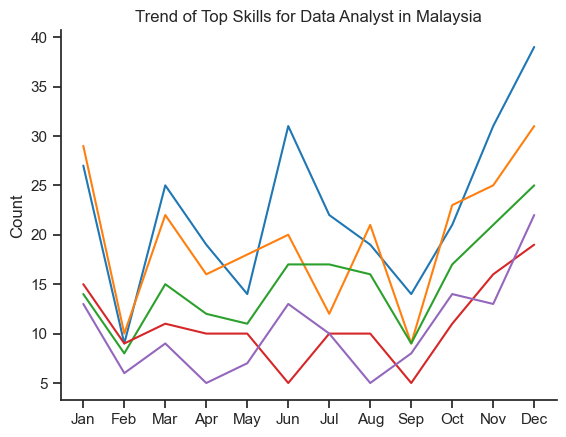

In [35]:
df_plot = df_da_my_pivot.iloc[:,:5]

sns.set_theme(style='ticks')

sns.lineplot(data=df_plot, dashes=False, legend='full', palette='tab10')
sns.despine()
plt.legend().remove()
plt.title('Trend of Top Skills for Data Analyst in Malaysia')
plt.xlabel('')
plt.ylabel('Count')

In [24]:
#get perentage of skills over total jobs
da_totals = df_da_my.groupby('job_posted_month_no').size()

da_totals

job_posted_month_no
1     66
2     32
3     49
4     37
5     42
6     43
7     38
8     40
9     24
10    47
11    83
12    78
dtype: int64

In [25]:
df_da_my_percent = df_da_my_pivot.iloc[:12].div(da_totals/100, axis=0)
df_da_my_percent

job_skills,sql,excel,python,power bi,tableau,r,sas,azure,hadoop,aws,...,docker,unity,airtable,no-sql,node.js,outlook,perl,c#,mongo,flask
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,40.909091,43.939394,21.212121,22.727273,19.696970,4.545455,18.181818,6.060606,12.121212,12.121212,...,0.000000,0.000000,1.515152,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
2,28.125000,31.250000,25.000000,28.125000,18.750000,15.625000,0.000000,9.375000,0.000000,3.125000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
3,51.020408,44.897959,30.612245,22.448980,18.367347,18.367347,16.326531,14.285714,8.163265,2.040816,...,0.000000,2.040816,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
4,51.351351,43.243243,32.432432,27.027027,13.513514,13.513514,10.810811,2.702703,8.108108,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.702703,0.000000,0.000000,0.0,0.000000,0.000000
5,33.333333,42.857143,26.190476,23.809524,16.666667,19.047619,14.285714,7.142857,2.380952,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
6,72.093023,46.511628,39.534884,11.627907,30.232558,23.255814,4.651163,18.604651,2.325581,11.627907,...,2.325581,0.000000,0.000000,2.325581,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
7,57.894737,31.578947,44.736842,26.315789,26.315789,10.526316,10.526316,10.526316,7.894737,7.894737,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2.631579
8,47.500000,52.500000,40.000000,25.000000,12.500000,12.500000,0.000000,5.000000,7.500000,2.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.5,0.000000,0.000000
9,58.333333,37.500000,37.500000,20.833333,33.333333,16.666667,25.000000,4.166667,4.166667,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000


In [26]:
#change month number to name
df_da_my_percent = df_da_my_percent.reset_index()
df_da_my_percent['job_posted_month'] = df_da_my_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_da_my_percent = df_da_my_percent.set_index('job_posted_month')
df_da_my_percent = df_da_my_percent.drop(columns='job_posted_month_no')

df_da_my_percent

job_skills,sql,excel,python,power bi,tableau,r,sas,azure,hadoop,aws,...,docker,unity,airtable,no-sql,node.js,outlook,perl,c#,mongo,flask
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,40.909091,43.939394,21.212121,22.727273,19.696970,4.545455,18.181818,6.060606,12.121212,12.121212,...,0.000000,0.000000,1.515152,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
Feb,28.125000,31.250000,25.000000,28.125000,18.750000,15.625000,0.000000,9.375000,0.000000,3.125000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
Mar,51.020408,44.897959,30.612245,22.448980,18.367347,18.367347,16.326531,14.285714,8.163265,2.040816,...,0.000000,2.040816,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
Apr,51.351351,43.243243,32.432432,27.027027,13.513514,13.513514,10.810811,2.702703,8.108108,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.702703,0.000000,0.000000,0.0,0.000000,0.000000
May,33.333333,42.857143,26.190476,23.809524,16.666667,19.047619,14.285714,7.142857,2.380952,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
Jun,72.093023,46.511628,39.534884,11.627907,30.232558,23.255814,4.651163,18.604651,2.325581,11.627907,...,2.325581,0.000000,0.000000,2.325581,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
Jul,57.894737,31.578947,44.736842,26.315789,26.315789,10.526316,10.526316,10.526316,7.894737,7.894737,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2.631579
Aug,47.500000,52.500000,40.000000,25.000000,12.500000,12.500000,0.000000,5.000000,7.500000,2.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.5,0.000000,0.000000
Sep,58.333333,37.500000,37.500000,20.833333,33.333333,16.666667,25.000000,4.166667,4.166667,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000


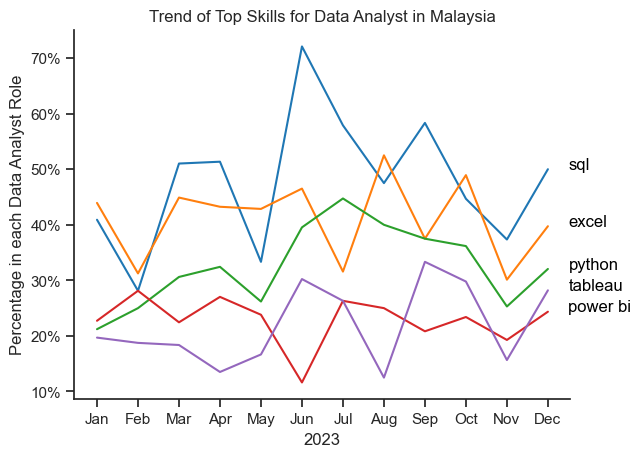

In [30]:
from matplotlib.ticker import PercentFormatter

df_plot = df_da_my_percent.iloc[:, :5]
sns.lineplot(data=df_plot, dashes=False, legend='full', palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

plt.title('Trend of Top Skills for Data Analyst in Malaysia')
plt.ylabel('Percentage in each Data Analyst Role')
plt.xlabel('2023')
plt.legend().remove()
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

# annotate the plot with the top 5 skills using plt.text()
for i in range(5):
    plt.text(11.5, df_plot.iloc[-1, i], df_plot.columns[i], color='black')